<a href="https://colab.research.google.com/github/ncbpsicologia/Bootcamp_ITacademy_DataAnalyst/blob/main/Sprint_9_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPRINT 9

## DESCRIPCIÓ

En aquest sprint treballaràs la interpretació analítica i el storytelling basat en dades, podràs utilitzar la base de dades que tens disponible a BigQuery o bé la base de dades creada amb MySQL al Sprint 2, a partir de l’exercici 8, i aprendràs a construir visualitzacions en Python com a alternativa programàtica a les eines de BI.

L'objectiu és aprendre a generar gràfics en Python i utilitzar-los per respondre preguntes de negoci. A més, hauràs de justificar les decisions preses i comunicar els resultats de manera clara i argumentada.

El teu paper com a analista serà:

» Entendre què se t'està preguntant des del punt de vista del negoci.
» Decidir quines visualitzacions són adequades per respondre cada pregunta.
» Construir aquestes visualitzacions en Python.
» Interpretar correctament què mostren les dades.
» Detectar possibles biaixos, limitacions o riscos en l'anàlisi.
» Proposar accions de negoci fonamentades en dades.
Aquest sprint posa l'èmfasi en l'ús de Python com a eina d'anàlisi visual, en el criteri analític i en la capacitat de transformar gràfics en decisions, més que en la sofisticació tècnica. Procura que el teu codi sigui clar i organitzat.

## Nivell 1 - Visualització analítica guiada en Python

L'objectiu del nivell és aplicar criteri analític per respondre preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del model del Sprint 2 a partir de l’exercici 8, carregades com a DataFrame independents.

En aquest nivell no es demana construir un dataset final ni unificar totes les taules, sinó:

- » Identificar quina informació és necessària.

- » Escollir correctament la taula (o taules) rellevant(s).

- » Construir visualitzacions adequades.

- » Interpretar els resultats obtinguts.

Aquest nivell posa l'èmfasi en pensar abans de programar.

## Exercici 1: Preguntes analítiques directes (sense integracions complexes)
🌍 Context: Es treballa amb **una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.**
Aspectes a revisar i analitzar:

- » Identificar quina informació és necessària. Quin DataFrame és el més adequat per respondre la pregunta.

- » Escollir correctament la taula (o taules) rellevant(s).

- » Tipus de variables implicades.

- » Elecció del tipus de gràfic.

Preguntes analítiques: (només utilitzant la taula de transaccions) :

1. Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

- Selecciona la columna temporal adequada.
- Defineix el nivell temporal d'anàlisi.
- Compta el nombre de registres per període temporal.
- Ordena els resultats cronològicament.
- Visualitza l'evolució amb un gràfic de línies amb pandas.

2. Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.

- Identifica la columna que representa el usuari.
- Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
- Ordena els usuaris de major a menor volum de facturació.
- Selecciona els N usuaris principals (per exemple, els 15 primers).
- Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

3. Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

- Crea una nova columna amb l'hora del dia a partir del timestamp.
- Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
- Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
- Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

4. Quins dies de la setmana es concentra més activitat de venda?

👉 Per a cada pregunta:
- Construeix una visualització senzilla en Python sense utilitzar IA.
- Interpreta breument el resultat obtingut.
- Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
- Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

### 1. Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

- Selecciona la columna temporal adequada.
- Defineix el nivell temporal d'anàlisi.
- Compta el nombre de registres per període temporal.
- Ordena els resultats cronològicament.
- Visualitza l'evolució amb un gràfic de línies amb pandas.

In [1]:
# Construeix una visualització senzilla en Python sense utilitzar IA.

# PASO 0

! pip install pandas # en principio en Colab no hace falta
import pandas as pd # importamos pandas

df = pd.read_csv("s2e8_transactions.csv", sep=";") # cargamos el archivo que indica el enunciado, con la especificación de indicar el separador

df.head() #visualizamos una muestra de las primeras filas del dataset

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,CcS-6894,b-2466,2018-12-12 08:05:17,176.45,0,"75, 73, 98",2313,59.620510,16.559977,20.72,35.29,0.00,store,CHRISTMAS_PEAK,pos,0,NaN,129.25
1,09456357-8E9B-475A-8257-87A023699964,CcS-5135,b-2342,2024-05-20 22:49:08,206.65,0,3,554,45.764588,4.843057,3.08,33.61,4.99,online,NO_CAMPAIGN,mobile,0,NaN,0.57
2,C47C7C84-C174-4973-A76B-825A9DB5582A,CcS-8415,b-2250,2018-11-04 23:16:18,548.77,0,"92, 85, 36, 23",3834,39.224213,-0.288066,43.76,95.24,0.00,marketplace,CATEGORY_PUSH,desktop,1,NaN,1498.24
3,2FB526AA-3844-4DDF-AC09-2EBCC255EE76,CcS-6553,b-2610,2022-06-17 09:17:25,411.55,0,"5, 27",1972,39.475985,-0.376419,4.03,71.43,0.00,store,NO_CAMPAIGN,pos,0,NaN,0.68
4,0D877407-B85E-40D2-9229-6BD6F2B8DF0A,CcS-7678,b-2454,2020-11-29 07:29:16,410.65,0,"38, 32, 82, 62",3097,51.436570,5.478526,95.72,71.27,0.00,marketplace,BLACK_FRIDAY,mobile,0,NaN,78.46


In [2]:
# PASO 1: Selecciona la columna temporal adequada.
df.columns

# La columna que debemos utilizar es 'timestamp', ya que contiene la información que necesitamos: fecha y hora de las transacciones

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km'],
      dtype='object')

In [3]:
# me aseguro que el formato sea fecha/hora

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].dtype

# según encuentro, este resultado es la representación interna que utiliza Pandas para indicar que la columna es de tipo fecha y hora (datetime). Así que podemos seguir

dtype('<M8[ns]')

In [4]:
# PASO 2: Defineix el nivell temporal d'anàlisi.

# Considero que una medida cómoda y adecuada para ver la evolución, es haciéndolo por mes. De este moodo, creo la columna 'mes':

df["mes"] = df["timestamp"].dt.to_period("M")

# compruebo que se ha añadido correctamente pidiendo una pequeña muestra aleatoria
df["mes"].sample(3)

,mes
62180,2020-08
30852,2017-01
32526,2024-03


In [5]:
# PASO 3: Compta el nombre de registres per període temporal.

# Aquí vamos a agrupar por mes (con groupby) y a contar las filas (con size). El número indica cuantas transacciones se han realizado ese mes

transacciones_mes = df.groupby("mes").size()

transacciones_mes

,0
mes,
2015-01,818
2015-02,816
2015-03,835
2015-04,829
2015-05,812
...,...
2024-08,824
2024-09,827
2024-10,823


In [6]:
# PASO 4: Ordena els resultats cronològicament.

# aunque sospecho que el groupby lo hace por defecto al ver el resultado anterior, me aseguro:
transacciones_mes = transacciones_mes.sort_index()

transacciones_mes.head(13)

,0
mes,
2015-01,818
2015-02,816
2015-03,835
2015-04,829
2015-05,812
2015-06,813
2015-07,830
2015-08,815
2015-09,822


<Axes: title={'center': 'Evolución de cantidad de transaccions'}, xlabel='Mes', ylabel='Cantidad'>

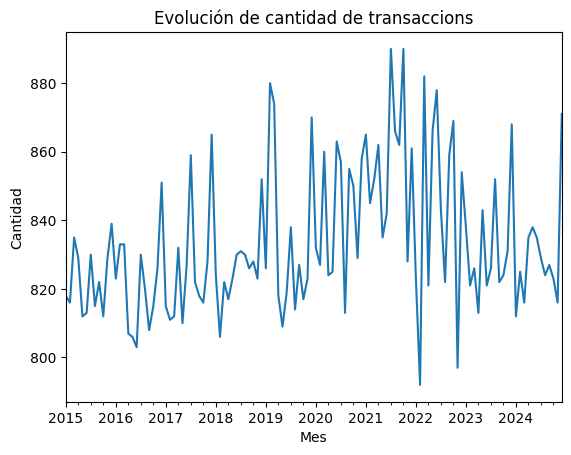

In [7]:
# PASO 5: Visualitza l'evolució amb un gràfic de línies amb pandas.

# al tratarse de una evolución en el tiempo, decido hacer un gráfico (.plot()) de línea (kind ="line")
# había consdierado el de barras pero sale una cantidad demasiado grande como para que sea tanto atractivo como entendedor
# por ir probando funcionalidades de formato o de presentación, añado el título y el nombre de los ejes x e y para mejorar la comprensión de lo que representan

transacciones_mes.plot(
    kind="line",
    title="Evolución de cantidad de transaccions",
    xlabel="Mes",
    ylabel="Cantidad"
)

In [8]:
# Interpreta breument el resultat obtingut.

'''
El número de transacciones mensuales se situa mayormente entre 800 y 880, aproximadamente (es relevante tener en cuenta que la separació entre valores en el eje Y es de 20).
Podemos observar que la cantidad de transacciones se mantiene relativamente estable con el paso de los años. Asimismo, sí presenta más variabilidad entre meses.
Por otro lado, aparentemente no se observa una tendencia concreta de crecimiento o disminución con el paso de los años.
Los picos más elevados se ubican entre el 2019 y el 2022, llegando hasta cerca de 900, mientras que los picos más bajos entre 2022 y 2023, acercándose hasta 780 aproximadamente.
Conclusión: La actividad de transacciones se mantiene bastante estable durante los años, pero hay bastante variabilidad entre meses.
'''

'\nEl número de transacciones mensuales se situa mayormente entre 800 y 880, aproximadamente (es relevante tener en cuenta que la separació entre valores en el eje Y es de 20).\nPodemos observar que la cantidad de transacciones se mantiene relativamente estable con el paso de los años. Asimismo, sí presenta más variabilidad entre meses.\nPor otro lado, aparentemente no se observa una tendencia concreta de crecimiento o disminución con el paso de los años.\nLos picos más elevados se ubican entre el 2019 y el 2022, llegando hasta cerca de 900, mientras que los picos más bajos entre 2022 y 2023, acercándose hasta 780 aproximadamente.\nConclusión: La actividad de transacciones se mantiene bastante estable durante los años, pero hay bastante variabilidad entre meses.\n'

In [9]:
# Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.

# Para este punto, doy el siguiente prompt a la cajita de Gemini integrada en Colab:
'''
"Para visualizar la evolución de la cantidad de transacciones a lo largo del tiempo he utilizado un gráfico de lineas.
Qué otra visualización consideras adecuada para esto?"
'''
# La respuesta ha sido:

'\n"Para visualizar la evolución de la cantidad de transacciones a lo largo del tiempo he utilizado un gráfico de lineas.\nQué otra visualización consideras adecuada para esto?"\n'

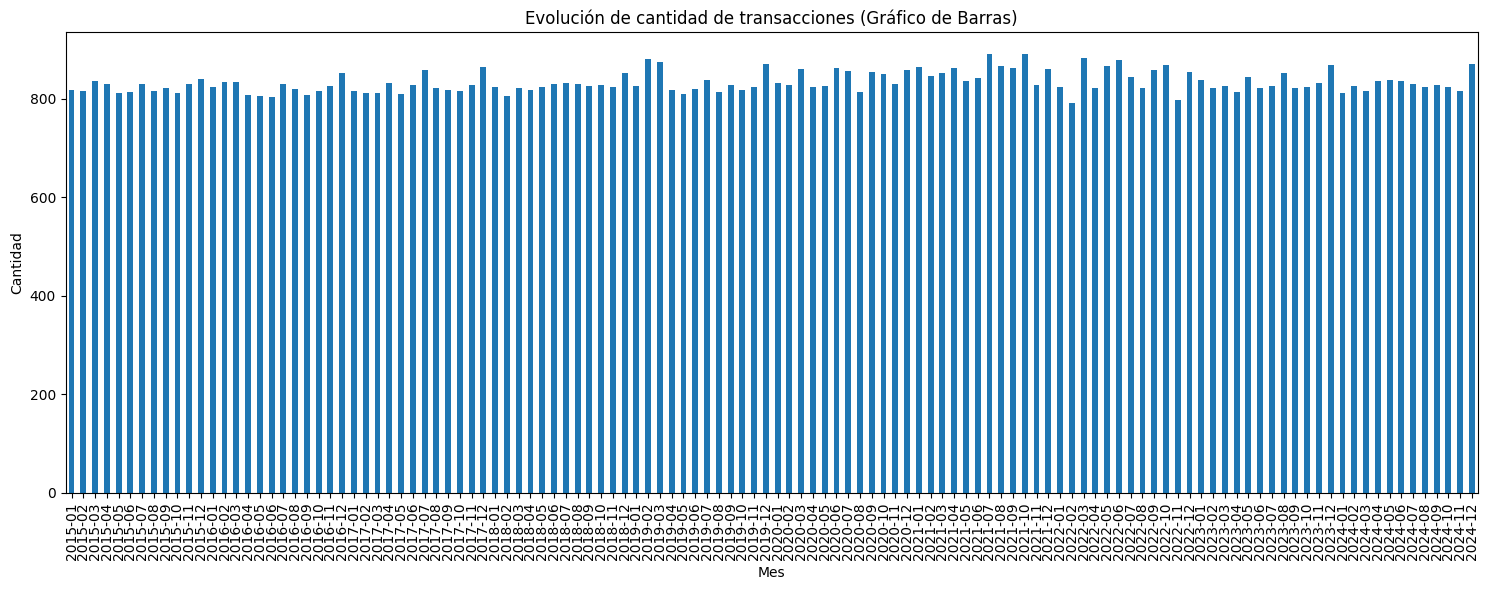

In [10]:
# esta celda la ha añadido Gemini directamente:

import matplotlib.pyplot as plt

# Visualize the evolution with a bar chart using pandas
transacciones_mes.plot(
    kind="bar",
    figsize=(15, 6), # Adjust figure size to better display the bars
    title="Evolución de cantidad de transacciones (Gráfico de Barras)",
    xlabel="Mes",
    ylabel="Cantidad"
)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Esta celda también la ha añadido directamente la IA:

A bar chart can also effectively show the monthly transaction counts. While it might appear more 'busy' than a line plot for a large number of periods, it clearly distinguishes the value for each month.

In [11]:
# Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

'''
El primer gráfico (líneas), permite ver de una manera muy cómoda la evolución de la cantidad de transacciones porque permite identificar tendencias (si las hay) y los picos.
Este hace "zoom" en la franja de cantidad de transacciones (aproximadamente 790 - 900) en el eje Y, pero en el eje X no aparecen los valores mes a mes.

El segundo gráfico (barras), al mostrar los mismos valores pero mes a mes (barra por mes), el eje X empieza des de 0 (no hace el "zoom" y es más difícil ver esas tendencias o picos.
Esto también hace que el gráfico se expanda bastante más horizontalmente.

En mi opinión, si no se quiere ver la comparación de mes a mes, sinó que se quiere ver solo la evolución de la cantidad a lo largo de los años, el primer gráfico es más adecuado, porque permite ver mejor la evolución temporal.
'''

'\nEl primer gráfico (líneas), permite ver de una manera muy cómoda la evolución de la cantidad de transacciones porque permite identificar tendencias (si las hay) y los picos.\nEste hace "zoom" en la franja de cantidad de transacciones (aproximadamente 790 - 900) en el eje Y, pero en el eje X no aparecen los valores mes a mes.\n\nEl segundo gráfico (barras), al mostrar los mismos valores pero mes a mes (barra por mes), el eje X empieza des de 0 (no hace el "zoom" y es más difícil ver esas tendencias o picos.\nEsto también hace que el gráfico se expanda bastante más horizontalmente.\n\nEn mi opinión, si no se quiere ver la comparación de mes a mes, sinó que se quiere ver solo la evolución de la cantidad a lo largo de los años, el primer gráfico es más adecuado, porque permite ver mejor la evolución temporal.\n'

### 2. Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.

- Identifica la columna que representa el usuari.
- Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
- Ordena els usuaris de major a menor volum de facturació.
- Selecciona els N usuaris principals (per exemple, els 15 primers).
- Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn



In [12]:
# Construeix una visualització senzilla en Python sense utilitzar IA.

# PASO 0
# como el enunciado nos pide que trabajemos con la librería seaborn, la importamos:

import seaborn as sns

df.head(2)

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km,mes
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,CcS-6894,b-2466,2018-12-12 08:05:17,176.45,0,"75, 73, 98",2313,59.620510,16.559977,20.72,35.29,0.00,store,CHRISTMAS_PEAK,pos,0,NaN,129.25,2018-12
1,09456357-8E9B-475A-8257-87A023699964,CcS-5135,b-2342,2024-05-20 22:49:08,206.65,0,3,554,45.764588,4.843057,3.08,33.61,4.99,online,NO_CAMPAIGN,mobile,0,NaN,0.57,2024-05


In [13]:
# PASO 1: Identifica la columna que representa el usuari.

df.columns

# la columna que identifica concretamente al usuario es user_id (importante no confundir con, por ejemplo, 'id' a secas, que identifica la transacción)

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes'],
      dtype='object')

In [14]:
# PASO 2:  Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.

# utilizo groupby para agrupar por usuario
# la operación (volumen total de facturación) la realizo mediante la suma (.sum()) de "amount", tal como indica el enunciado

facturacion_usuario = df.groupby("user_id")["amount"].sum()

facturacion_usuario.sample(3) #pido una pequeña muestra aleatoria como comprobación

,amount
user_id,
3477,5731.46
3327,4545.07
2895,6242.75


In [15]:
# PASO 3: Ordena els usuaris de major a menor volum de facturació.

# para asegurar que ordenamos los valores de mayor a menor, tenemos que especificar que el orden sea descendiente mediante ascending=False

facturacion_usuario = facturacion_usuario.sort_values(ascending=False)

facturacion_usuario.head(10) # comprobamos viendo las primeras filas

,amount
user_id,
289,47332.90
318,47133.55
455,41396.68
417,37393.91
185,34576.49
285,33383.56
454,29528.42
349,27835.38
193,27462.59


In [16]:
# PASO 4: Selecciona els N usuaris principals (per exemple, els 15 primers).

# el enunciado nos pide que nos quedemos con los 15 usuarios, por lo que guardaremos los 15 primeros registros:

top_15 = facturacion_usuario.head(15)

top_15 #comprobamos

,amount
user_id,
289,47332.90
318,47133.55
455,41396.68
417,37393.91
185,34576.49
285,33383.56
454,29528.42
349,27835.38
193,27462.59


In [17]:
# PASO 5: Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

'''
sns.barplot(
    data=top_15,
    x="user_id",
    y="amount"
)
'''
# Sale error por estr trabajando con una Serie en vez de un DataFrame, lo soluciono a continuación

'\nsns.barplot(\n    data=top_15,\n    x="user_id",\n    y="amount"\n)\n'

In [18]:
top_15 = top_15.reset_index()

# comprobamos
type(top_15)
# ahora sí

pandas.core.frame.DataFrame

[Text(0.5, 1.0, 'Top 15 usuarios per volumen de facturación'),
 Text(0.5, 0, 'Usuario (id)'),
 Text(0, 0.5, 'Volumen de facturación')]

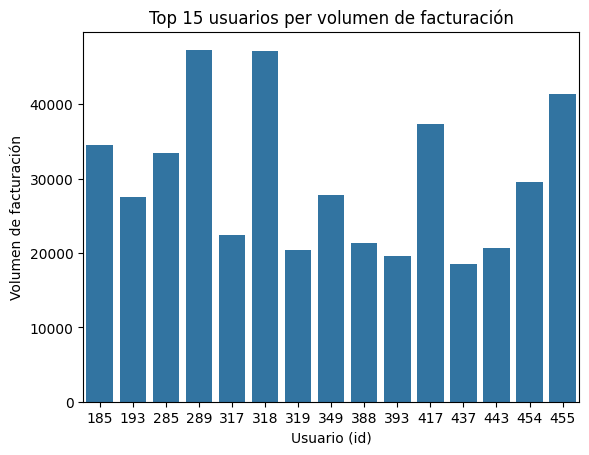

In [19]:
# en la primera parte de código, creo la base del gráfico

sns.barplot(
    data=top_15,
    x="user_id",
    y="amount"

# en esta segunda parte, facilito su interpretación añadiendo etiquetas
).set(
    title="Top 15 usuarios per volumen de facturación",
    xlabel="Usuario (id)",
    ylabel="Volumen de facturación"
)

In [20]:
# Interpreta breument el resultat obtingut.

'''
Hay diferencias considerables en el volumen de facturación entre los usuarios del top 15.
Los usuarios con una facturación más elevada son el 289 y el 318, que superan los 45k, y de muy cerca el 455, superando los 40k.
Los usuarios con una facturación más baja, son el 437 y el 393, que no llegan a 20k, seguidos muy de cerca por 319, 443, 388 y 317, que superan por poco los 20k.
'''

'\nHay diferencias considerables en el volumen de facturación entre los usuarios del top 15.\nLos usuarios con una facturación más elevada son el 289 y el 318, que superan los 45k, y de muy cerca el 455, superando los 40k.\nLos usuarios con una facturación más baja, son el 437 y el 393, que no llegan a 20k, seguidos muy de cerca por 319, 443, 388 y 317, que superan por poco los 20k.\n'

In [21]:
# Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.

# El prompt que doy a la cajita de la IA es el siguiente:
'''
"Para visualizar el volumen de facturación de cada usuario utilizado un gráfico barras verticales.
Qué otra visualización consideras adecuada para esto?"
'''
# La respuesta ha sido:

'\n"Para visualizar el volumen de facturación de cada usuario utilizado un gráfico barras verticales.\nQué otra visualización consideras adecuada para esto?"\n'

In [22]:
# celda isnertada directamente por la IA

# Lo pongo así para que no afecte a la ejecución del resto de celdas:
'''

import matplotlib.pyplot as plt

# Create a horizontal bar chart for the top 15 users by billing volume
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability of horizontal bars
sns.barplot(
    data=top_15,
    y="user_id", # User IDs on the y-axis
    x="amount",  # Amount on the x-axis
    orient='h'   # Set orientation to horizontal
)
.set(
    title="Top 15 usuarios por volumen de facturación (Horizontal)",
    xlabel="Volumen de facturación",
    ylabel="Usuario (id)"
)
plt.tight_layout()
plt.show()
'''

# (al ejecutarla, da el siguiente error:
'''
  File "/tmp/ipykernel_684/2634565749.py", line 13
    .set(
    ^
SyntaxError: invalid syntax)
'''

'\n  File "/tmp/ipykernel_684/2634565749.py", line 13\n    .set(\n    ^\nSyntaxError: invalid syntax)\n'

Celda insertada directamente por la IA;

A horizontal bar chart presents the same information but can be easier to read when category labels (like user IDs) are long or numerous, preventing overlap of labels on the x-axis.

[Text(0.5, 1.0, 'Top 15 usuarios per volumen de facturación'),
 Text(0.5, 0, 'Usuario (id)'),
 Text(0, 0.5, 'Volumen de facturación')]

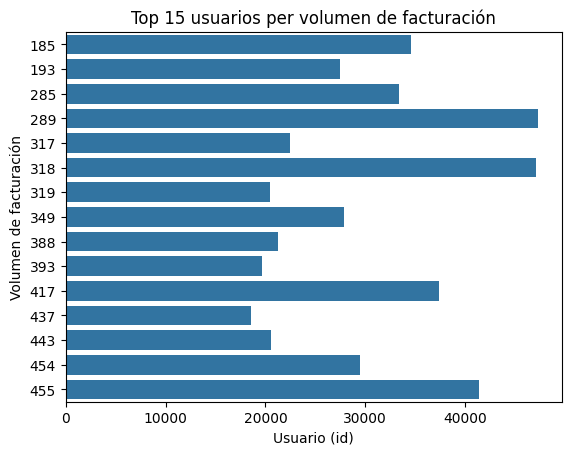

In [23]:
# Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

# Da error al ejecutar, pero se refiere a un gráfico de barras horizontal. Lo hago de manera más sencilla (la que conozco) a continuación:

sns.barplot(
    data=top_15,
    x="amount",
    y="user_id",
    orient='h'

# en esta segunda parte, facilito su interpretación añadiendo etiquetas
).set(
    title="Top 15 usuarios per volumen de facturación",
    xlabel="Usuario (id)",
    ylabel="Volumen de facturación"
)

In [24]:
# Ahora si, la comparación:

'''
En el gráfico de barras verticales, el eje X contiene el user_id y el eje Y el amount.
Permite comparar fácilmente la altura de las barras (amount).
En el gráfico de barras horizontales, los valores de X e Y se intercambian, poniendo el user_id en el eje Y y el amount en el eje X.
Permite comparar fácilmente la largada de las barras (amount).

En este caso, aunque ambos son bastante claros, considero que es más adecuado el gráfico de barras horizontales principalmente por un motivo: las etiquetas de user_id.
Con 15 y además siendo cortas (3 dígitos en este caso), las etiquetas quedan juntas pero todavía se pueden leer bien. Si queremos añadir algunos usuarios más, quedarían demasiado juntas y dificultarían la legibilidad.
'''

'\nEn el gráfico de barras verticales, el eje X contiene el user_id y el eje Y el amount.\nPermite comparar fácilmente la altura de las barras (amount).\nEn el gráfico de barras horizontales, los valores de X e Y se intercambian, poniendo el user_id en el eje Y y el amount en el eje X.\nPermite comparar fácilmente la largada de las barras (amount).\n\nEn este caso, aunque ambos son bastante claros, considero que es más adecuado el gráfico de barras horizontales principalmente por un motivo: las etiquetas de user_id.\nCon 15 y además siendo cortas (3 dígitos en este caso), las etiquetas quedan juntas pero todavía se pueden leer bien. Si queremos añadir algunos usuarios más, quedarían demasiado juntas y dificultarían la legibilidad.\n'

### 3. Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

- Crea una nova columna amb l'hora del dia a partir del timestamp.
- Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
- Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
- Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.



In [25]:
# Construeix una visualització senzilla en Python sense utilitzar IA.

# PASO 0: importaríamos seaborn pero ya está del ejercicio anterior

df.columns #para recordar los nombres

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes'],
      dtype='object')

In [26]:
# PASO 1: Crea una nova columna amb l'hora del dia a partir del timestamp.

# De manera similar al primer ejercicio, ahora creamos la columna 'hora'

df["hora"] = df["timestamp"].dt.hour

# compruebo que se ha añadido correctamente pidiendo una pequeña muestra aleatoria
df[["timestamp", "hora"]].sample(3)

,timestamp,hora
10039,2018-01-23 01:16:20,1
87187,2015-05-21 06:34:59,6
50465,2017-05-02 11:26:58,11


<Axes: xlabel='hora', ylabel='amount'>

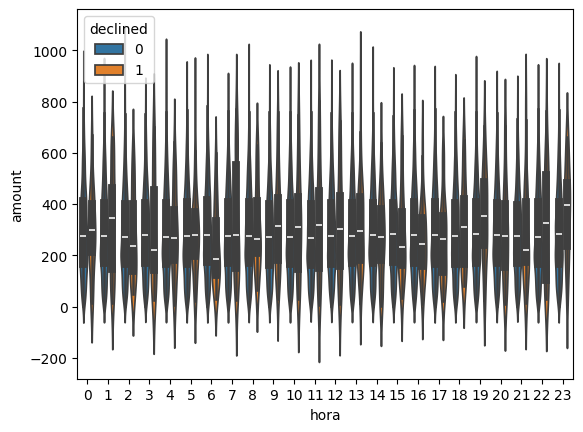

In [27]:
# PASO 2: Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
# PASO 3: Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.

sns.violinplot( #indicamos el tipo de gráfico que dice el enunciado
    data=df, #de donde saco los datos
    x="hora", #qué variable va en el eje x
    y="amount", #cual en el y
    hue="declined") #separamos las transacciones segun si estan aceptadas o no)

# (declined = 0 aceptadas, declined = 1 rechazadas)

<Axes: xlabel='hora', ylabel='amount'>

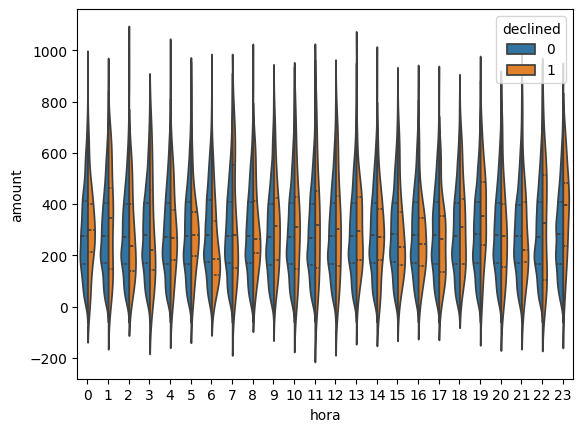

In [28]:
# PASO 4: Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

sns.violinplot( #indicamos el tipo de gráfico que dice el enunciado
    data=df, #de donde saco los datos
    x="hora", #qué variable va en el eje x
    y="amount", #cual en el y
    hue="declined", #separamos las transacciones segun si estan aceptadas o no)
    split=True, # comparar aceptadas y rechazadas
    inner="quartile") # mostrar mediana y quartiles

In [29]:
# Interpreta breument el resultat obtingut.

'''
Este gráfico muestra que los importe de las transacciones (independientemente de si estan aceptadas o rechazadas) se centran en su mayoría entre 100 y 500, aproximadamente, aunque hay valores que salen de este rango.
En las transacciones aceptadas, la mediana parece ubicarse por debajo de 300, cercana a ese valor.
En cambio, en las transacciones rechazadas, la mediana parece tener más variabilidad en función de las horas (por ejemplo, a las 6h es visiblemente inferior que a las 23h)
De este modo, en algunas horas se llegan a observar diferencias entre las transacciones aceptadas y las rechazadas, pero estas no muestran un patrón claro/constante.
Por tanto, la hora del dia parece tener poca influencia sobre el importe de las transacciones aceptadas, pero es posible que esta afectara en las rechazadas.
'''


'\nEste gráfico muestra que los importe de las transacciones (independientemente de si estan aceptadas o rechazadas) se centran en su mayoría entre 100 y 500, aproximadamente, aunque hay valores que salen de este rango.\nEn las transacciones aceptadas, la mediana parece ubicarse por debajo de 300, cercana a ese valor.\nEn cambio, en las transacciones rechazadas, la mediana parece tener más variabilidad en función de las horas (por ejemplo, a las 6h es visiblemente inferior que a las 23h)\nDe este modo, en algunas horas se llegan a observar diferencias entre las transacciones aceptadas y las rechazadas, pero estas no muestran un patrón claro/constante.\nPor tanto, la hora del dia parece tener poca influencia sobre el importe de las transacciones aceptadas, pero es posible que esta afectara en las rechazadas.\n'

In [30]:
# Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.

# El prompt que doy a la cajita de la IA es el siguiente:
'''
"Para visualizar la distribución del importe de las transacciones segun la hora del día y si han estado aceptadas o rechazadas, he utilizado un gráfico barras verticales.
Qué otra visualización consideras adecuada para esto?"
'''
# La respuesta ha sido:

'\n"Para visualizar la distribución del importe de las transacciones segun la hora del día y si han estado aceptadas o rechazadas, he utilizado un gráfico barras verticales.\nQué otra visualización consideras adecuada para esto?"\n'

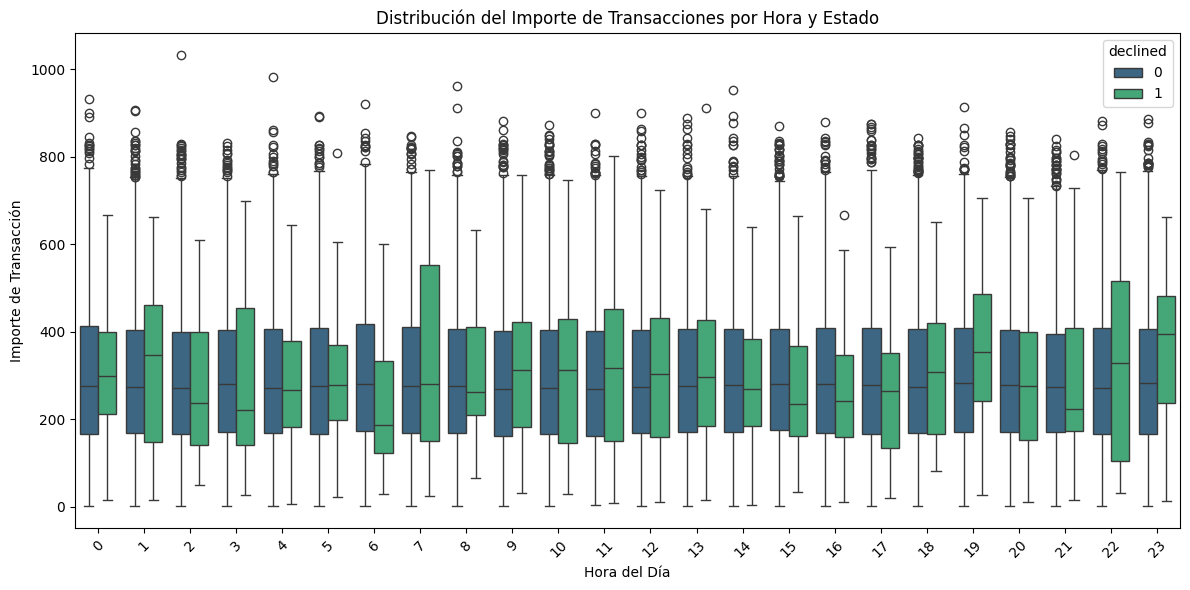

In [31]:
# celda insertada directamente por la IA

import matplotlib.pyplot as plt

# Create a box plot to visualize the distribution of transaction amounts
plt.figure(figsize=(12, 6)) # Adjust figure size
sns.boxplot(
    data=df, # Dataframe
    x="hora", # Hour on the x-axis
    y="amount", # Amount on the y-axis
    hue="declined", # Split by transaction status (accepted/rejected)
    palette="viridis" # Choose a color palette
)
plt.title("Distribución del Importe de Transacciones por Hora y Estado") # Add title
plt.xlabel("Hora del Día") # Add x-axis label
plt.ylabel("Importe de Transacción") # Add y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.tight_layout() # Adjust layout
plt.show()

Celda insertada directamente por la IA:

A box plot offers a more simplified view of the distribution compared to a violin plot, highlighting the median, quartiles, and potential outliers. It's particularly useful for comparing these key statistical measures across different categories (hours and transaction status in this case).

In [32]:
# Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

'''
El violinplot nos ha permitido observar con más detalle, con la forma, la densidad de las distribuciones, pero al tener 24 categorías (horas del día), dificulta la comparación visual.
El boxplot simplifica esa información. También permite comparar de manera más clara medidas como medianas, cuartiles y valores atípicos entre un grupo de transacciones y otras.

En este caso, considero más adecuada la alternativa aportada por la IA: el boxplot.
'''

'\nEl violinplot nos ha permitido observar con más detalle, con la forma, la densidad de las distribuciones, pero al tener 24 categorías (horas del día), dificulta la comparación visual.\nEl boxplot simplifica esa información. También permite comparar de manera más clara medidas como medianas, cuartiles y valores atípicos entre un grupo de transacciones y otras.\n\nEn este caso, considero más adecuada la alternativa aportada por la IA: el boxplot.\n'

### 4. Quins dies de la setmana es concentra més activitat de venda?

In [33]:
# Construeix una visualització senzilla en Python sense utilitzar IA.

# PASO 0

df.columns

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes', 'hora'],
      dtype='object')

In [34]:
# PASO 1 --> Voy a crear una nueva columna con los días de la semana "dia" a partir del timestamp.

df["dia"] = df["timestamp"].dt.day_name()

# compruebo que se ha añadido correctamente pidiendo una pequeña muestra aleatoria
df[["timestamp", "dia"]].sample(3)

,timestamp,dia
91077,2019-11-20 08:46:40,Wednesday
66234,2021-06-13 13:55:33,Sunday
72093,2021-02-10 08:06:14,Wednesday


In [35]:
# PASO 2 --> para ver qué día de la semana hay más actividad, realizaré un recuento de las transacciones que se hacen cada día
ventas_dia = df["dia"].value_counts()

ventas_dia
# por defecto, se pone en orden descendiente

,count
dia,
Thursday,14516
Saturday,14353
Sunday,14289
Friday,14272
Wednesday,14272
Tuesday,14176
Monday,14122


In [36]:
# lo convierto a dataframe, por evitar el error de antes

ventas_dia = df["dia"].value_counts().reset_index()

[Text(0.5, 1.0, 'Cantidad de transacciones por dia de la setmana'),
 Text(0.5, 0, 'Dia'),
 Text(0, 0.5, 'Cantidad de transaccions'),
 (14000.0, 14600.0)]

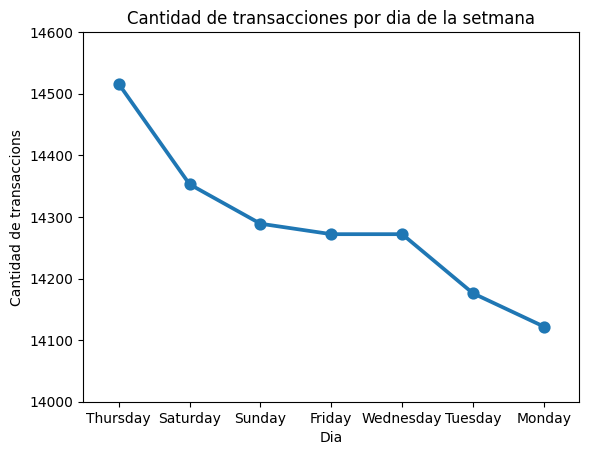

In [37]:
# PASO 3 --> voy a realizar una visualización con un diagrama puntos, ya que hay pocas categorías

sns.pointplot(
    data=ventas_dia,
    x="dia",
    y="count"
).set(
    title="Cantidad de transacciones por dia de la setmana",
    xlabel="Dia",
    ylabel="Cantidad de transaccions",
    ylim=(14000, 14600)
)

In [38]:
# creo que quedaría más intuitivo si ordeno los días de la semana cronológicamente y no según la actividad transaccional

orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

ventas_dia["dia"] = pd.Categorical(
    ventas_dia["dia"],
    categories=orden_dias,
    ordered=True
)

ventas_dia = ventas_dia.sort_values("dia")

<Axes: xlabel='dia', ylabel='count'>

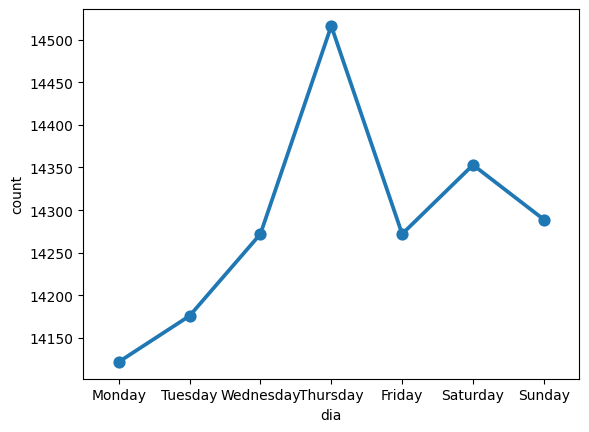

In [39]:
sns.pointplot(
    data=ventas_dia,
    x="dia",
    y="count"
)

#aquí es más intuitiva la lectura de qué día de la semana hay más actividad y como evoluciona a lo largo de la semana

In [40]:
# Interpreta breument el resultat obtingut.

'''
Los valores se comprenden entre 14100 y 1550 aproximadamente. La mayoría estan entre 1280 y 1350, aproximadamente.
En este caso, el inicio de la semana cuenta con menos actividad, siendo lunes el día con menos transacciones (14100 aproximadamente), seguido de martes y de miércoles (que alcanza algo más de 14250).
Jueves hay un repunte considerable de actividad, llegando a los valores máximos (cerca de 14500)
Viernes desciende la actividad hasta los niveles de miércoles, Sábado vuelve a haber un pequeño repunte y domingo vuelve a descender a niveles similares a miércoles y viernes
'''

'\nLos valores se comprenden entre 14100 y 1550 aproximadamente. La mayoría estan entre 1280 y 1350, aproximadamente.\nEn este caso, el inicio de la semana cuenta con menos actividad, siendo lunes el día con menos transacciones (14100 aproximadamente), seguido de martes y de miércoles (que alcanza algo más de 14250).\nJueves hay un repunte considerable de actividad, llegando a los valores máximos (cerca de 14500)\nViernes desciende la actividad hasta los niveles de miércoles, Sábado vuelve a haber un pequeño repunte y domingo vuelve a descender a niveles similares a miércoles y viernes\n'

In [41]:
# Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.

# El prompt que doy a la cajita de la IA es el siguiente:
'''
"Para visualizar qué día de la semana hay más actividad en ventas, he utilizado un gráfico de puntos.
Qué otra visualización consideras adecuada para esto?"
'''
# La respuesta ha sido:

'\n"Para visualizar qué día de la semana hay más actividad en ventas, he utilizado un gráfico de puntos.\nQué otra visualización consideras adecuada para esto?"\n'

/tmp/ipykernel_3491/4169701918.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


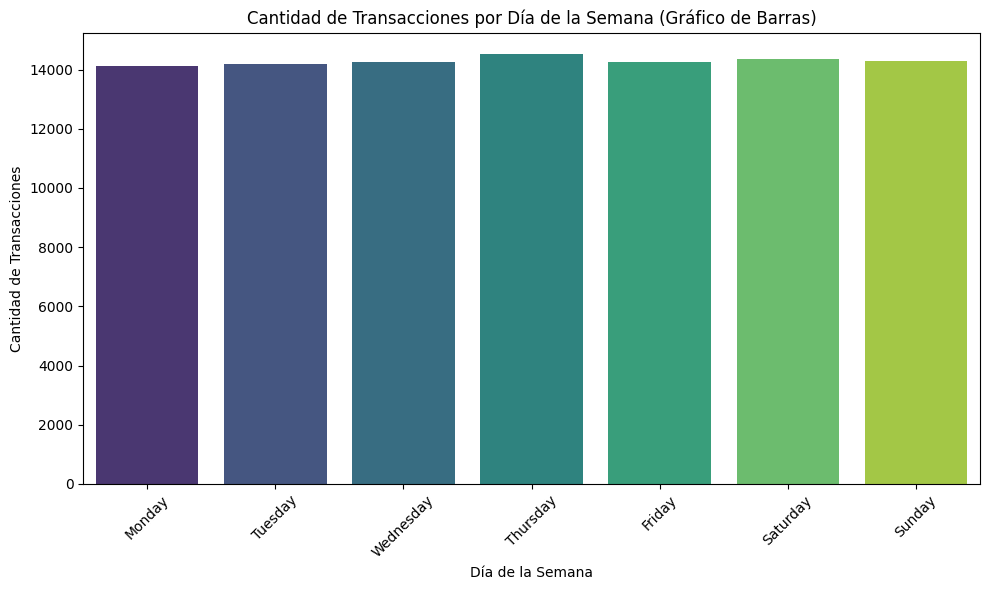

In [42]:
# celda insertada directamente por la IA:

import matplotlib.pyplot as plt

# Create a bar chart to visualize the number of transactions per day of the week
plt.figure(figsize=(10, 6)) # Adjust figure size
sns.barplot(
    data=ventas_dia,
    x="dia", # Day of the week on the x-axis
    y="count", # Transaction count on the y-axis
    palette="viridis" # Choose a color palette
)
plt.title("Cantidad de Transacciones por Día de la Semana (Gráfico de Barras)") # Add title
plt.xlabel("Día de la Semana") # Add x-axis label
plt.ylabel("Cantidad de Transacciones") # Add y-axis label
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout
plt.show()

Celda insertada directamente por la IA

A bar chart offers a clear visual comparison of the total number of transactions for each day of the week. While a point plot shows the trend, a bar chart clearly emphasizes the magnitude of transactions for each individual day.

In [43]:
# Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

'''
El gráfico de puntos (unidos por la línea) permiten ver de manera muy clara la diferencia entre días.
En el gráfico de barras, como las diferencias son pequeñas (unas 400 transacciones de diferencia entre el valor mínimo y el máximo, sobre las más de 14000), cuesta más percibirlas visualmente (las barras tienen alturas más similares)
De este modo, considero que en este caso el primer gráfico es más adecuado.
'''

'\nEl gráfico de puntos (unidos por la línea) permiten ver de manera muy clara la diferencia entre días.\nEn el gráfico de barras, como las diferencias son pequeñas (unas 400 transacciones de diferencia entre el valor mínimo y el máximo, sobre las más de 14000), cuesta más percibirlas visualmente (las barras tienen alturas más similares)\nDe este modo, considero que en este caso el primer gráfico es más adecuado.\n'

## Exercici 2: Preguntes analítiques complexes (amb guia)
🌍 Context: Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

Preguntes analítiques (amb guia general)

» Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

» Existeix estacionalitat en les vendes?

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

» Anàlisi de concentració i variabilitat (tria UNA opció)

Opció A – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

Opció B – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

👉 Per a cada pregunta:

» Descriu breument els passos seguits.

» Mostra la visualització final.

» Interpreta què implica per al negoci.

PRIMERA PREGUNTA
» Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

Combinar la informació de transaccions amb la de companyies.

Agrupar la facturació per país.

Calcular la facturació total generada per cada país.

Ordenar els països de major a menor facturació.

Calcular el percentatge acumulat sobre el total.

Visualitzar.



In [44]:
# Descriu breument els passos seguits.

'''
Sigo los pasos orientativos del ejercicio:
- Combino la info de la tabla transacciones (df) con la de companies (df2) mediante merge, en un nuevo df (df_trans_comp)
- Agrupo la facturacion por país mediante groupby (calculando con sum() la facturación total de cada uno)
- Ordeno los países descendientemente con sort_values
- Calculo el porcentaje acumulado sobre el total mediante cumsum()
- Creo la visualización
'''

'\nSigo los pasos orientativos del ejercicio:\n- Combino la info de la tabla transacciones (df) con la de companies (df2) mediante merge, en un nuevo df (df_trans_comp)\n- Agrupo la facturacion por país mediante groupby (calculando con sum() la facturación total de cada uno)\n- Ordeno los países descendientemente con sort_values\n- Calculo el porcentaje acumulado sobre el total mediante cumsum()\n- Creo la visualización\n'

In [45]:
# ya hemos importado pandas en el ejercicio anterior
# importamos el archivo que necesitamos

df2 = pd.read_csv("s2e8_companies.csv") # cargamos el archivo que indica el enunciado

df2.head()

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


In [46]:
print("columnas de transactions")
df.columns

columnas de transactions


Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes', 'hora', 'dia'],
      dtype='object')

In [47]:
print("columnas de companies")
df2.columns

columnas de companies


Index(['company_id', 'company_name', 'phone', 'email', 'country', 'website',
       'merchant_category', 'merchant_price_position'],
      dtype='object')

In [48]:
# De nuestro primer df (transactions), a priori, emplearemos las columnas id (para las transacciones) y amount
# De nuestro segundo df (companies), a priori, emplearemos las columnas company_id (para las compañías) y country
# El merge de ambas, lo realizaremos con business_id y company_id respectivamente

df_trans_comp = df.merge(
    df2,
    left_on="business_id",
    right_on="company_id"
)

# comprobamos

df_trans_comp[["business_id", "company_id", "country", "amount"]].sample(5)

,business_id,company_id,country,amount
80319,b-2346,b-2346,Sweden,329.29
34991,b-2266,b-2266,Sweden,273.11
19412,b-2382,b-2382,Ireland,565.89
57884,b-2610,b-2610,Italy,495.54
56844,b-2498,b-2498,Australia,633.36


In [49]:
# para agrupar la facturación por pais, uso groupby

facturacion_pais = df_trans_comp.groupby("country")["amount"].sum()

facturacion_pais

,amount
country,
Australia,699013.06
Belgium,952208.75
Canada,558568.76
China,239034.47
France,1416084.26
Germany,4020364.07
Ireland,715220.46
Italy,4087557.38
Netherlands,4506571.38


In [50]:
# ordeno de mayor a menor

facturacion_pais = facturacion_pais.sort_values(ascending=False)

facturacion_pais

,amount
country,
Sweden,4928290.24
Netherlands,4506571.38
United Kingdom,4099117.08
Italy,4087557.38
Germany,4020364.07
France,1416084.26
United States,1101737.27
Belgium,952208.75
Norway,809288.82


In [51]:
#calculo que porcentaje representa cada país sobre el total y con cumsum hago el acumulado

facturacion_pais_acum = (facturacion_pais / facturacion_pais.sum() * 100).cumsum().round(2)

facturacion_pais_acum

,amount
country,
Sweden,16.82
Netherlands,32.21
United Kingdom,46.20
Italy,60.15
Germany,73.87
France,78.71
United States,82.47
Belgium,85.72
Norway,88.48


'\nVemos que hay mucha diferencia entre los países que más facturan (Alemania, Italia, Reino Unido, Paises Bajos y Suecia) y los que menos (China, España, Caada, Australia, Nueva Zelanda, Irlanda, Noruega, Bélgica, Estados Unidos y Francia)\nPero igual no acaba de quedar claro el % para responder con claridad a la pregunta del enunciado\n'

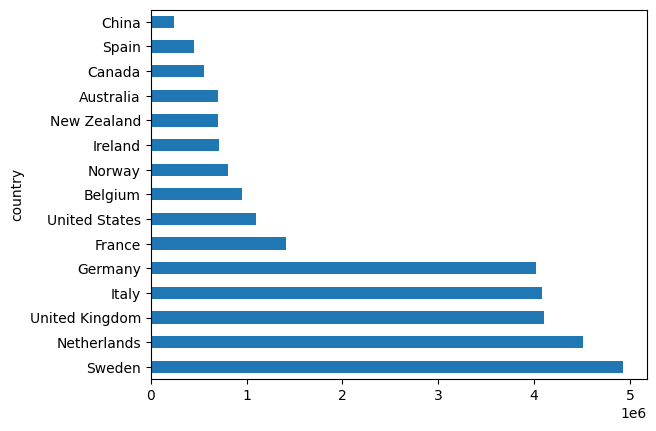

In [52]:
# Mostra la visualització final.

# Decido hacer un gráfico de barras horizontales para la visualización

facturacion_pais.plot(kind="barh")

# nota para mi: abajo a la derecha, el 1e6 significa 1 × 10⁶, es decir, 1.000.000.
# entonces, la barra de Suecia llega aprox a 4,9 × 10⁶ = 4.900.000 de facturación.

'''
Vemos que hay mucha diferencia entre los países que más facturan (Alemania, Italia, Reino Unido, Paises Bajos y Suecia) y los que menos (China, España, Caada, Australia, Nueva Zelanda, Irlanda, Noruega, Bélgica, Estados Unidos y Francia)
Pero igual no acaba de quedar claro el % para responder con claridad a la pregunta del enunciado
'''

<Axes: title={'center': 'Percentatge acumulat de facturació per país'}, xlabel='Percentatge acumulat (%)', ylabel='País'>

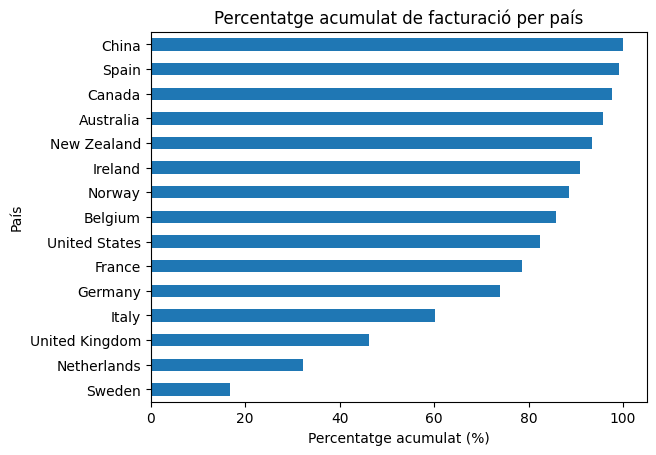

In [53]:
# utilizaré facturacion_pais_acum

facturacion_pais_acum.plot(
    kind="barh",
    title="Percentatge acumulat de facturació per país",
    xlabel="Percentatge acumulat (%)",
    ylabel="País"
)

In [54]:
'''
En este gráfico si se ve mejor la información que necesitamos
Por ejemplo, Suecia por si sola tiene un peso de aproximadamente 18%, Suecia + Países Bajos de aproximadamente 33%, etc.
El gráfico muestra que la facturación se concentra sobretodo en los primeros países (los que están más abajo en este segundo gráfico), tienen más peso en la facturación total
'''

'\nEn este gráfico si se ve mejor la información que necesitamos\nPor ejemplo, Suecia por si sola tiene un peso de aproximadamente 18%, Suecia + Países Bajos de aproximadamente 33%, etc.\nEl gráfico muestra que la facturación se concentra sobretodo en los primeros países (los que están más abajo en este segundo gráfico), tienen más peso en la facturación total\n'

In [55]:
# Interpreta què implica per al negoci.

'''
Respondiendo a la pregunta del enunciado, "Depenem excessivament d'un nombre reduït de països de companyies venedores?"

Según el gráfico que muestra los datos, si existe una concentración significativa de la facturación en un númeor reducido de países.
Los cinco primeros paises acumulan aproximadamente un 75% de la facturación, viendo que una parte importante de los ingresos dependen de un número reducido de paises.
De este modo, la empresa tiene cierta dependencia geográfica.
'''

'\nRespondiendo a la pregunta del enunciado, "Depenem excessivament d\'un nombre reduït de països de companyies venedores?"\n\nSegún el gráfico que muestra los datos, si existe una concentración significativa de la facturación en un númeor reducido de países.\nLos cinco primeros paises acumulan aproximadamente un 75% de la facturación, viendo que una parte importante de los ingresos dependen de un número reducido de paises.\nDe este modo, la empresa tiene cierta dependencia geográfica.\n'

SEGONA PREGUNTA
» Existeix estacionalitat en les vendes?

Passos orientatius:

Treballar amb dates de transacció.

Extreure la informació temporal rellevant (any i mes).

Calcular el volum total de vendes (suma de amount) per any i mes.

Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

Visualitzar l'evolució.



In [56]:
# Descriu breument els passos seguits.
'''
Sigo los pasos orientativos del enunciado:
- Para trabajar con la información temporal relevante de df (transactions), utilizaré las columnas mes y año (creadas por mi)
- Calculo el volumen total de ventas (suma del amount) agrupando con groupby año y mes
- Creo una tabla tipo pivot con pd.pivot_table
- Le doy formato al df por testear un poco y empezar a facilitar la lectura
- Genero la visualización final para ver la evolución
'''

'\nSigo los pasos orientativos del enunciado:\n- Para trabajar con la información temporal relevante de df (transactions), utilizaré las columnas mes y año (creadas por mi)\n- Calculo el volumen total de ventas (suma del amount) agrupando con groupby año y mes\n- Creo una tabla tipo pivot con pd.pivot_table\n- Le doy formato al df por testear un poco y empezar a facilitar la lectura\n- Genero la visualización final para ver la evolución\n'

In [57]:
# al ir a crear la columna año me sale error porque "timestamp" no está en formato fecha, lo he comprobado con df["timestamp"].dtype y sale dtype('O') que significa 'object'
# primero la convierto

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["timestamp"].dtype #ahora sí (dtype('<M8[ns]'))

dtype('<M8[ns]')

In [58]:
# la creamos

df["año"] = df["timestamp"].dt.year

# compruebo que se ha añadido correctamente pidiendo una pequeña muestra aleatoria
#al hacer: df[["timestamp", "año", "mes"]].sample(3) me sale de error que "mes" no está creada. al hacer df.columns lo confirmo

#vuelvo a crear la columna "mes"

df["mes"] = df["timestamp"].dt.month

df[["timestamp", "año", "mes"]].sample(3)

,timestamp,año,mes
23743,2022-09-06 13:32:13,2022,9
54466,2019-08-22 08:31:25,2019,8
52045,2022-09-27 01:51:29,2022,9


In [59]:
# ahora debo calcular el amount por año y mes

ventas_estacionales = df.groupby(["año", "mes"])['amount'].sum()

ventas_estacionales

año   mes
2015  1      224946.23
      2      248775.83
      3      254702.98
      4      247957.49
      5      252596.43
               ...    
2024  8      239210.63
      9      236592.54
      10     255720.13
      11     236354.15
      12     251688.94
Name: amount, Length: 120, dtype: float64

In [60]:
#para crear la tabla tipo pivot que nos pide el enunciado, en este caso se podría hacer con unstack, convirtiendo los meses a columnas
#como ya lo vi anteriormente, usaré pivot_table, ya que tengo entendido que es la manera de pandas para realizar tablas dinámicas y goza de mayor flexibilidad (aunque no hubiese sido necesario el groupby anterior)

tabla_pivot = pd.pivot_table(
    df,
    values="amount",
    index="año",
    columns="mes",
    aggfunc="sum"
)

tabla_pivot

mes,1,2,3,4,5,6,7,8,9,10,11,12
año,,,,,,,,,,,,
2015,224946.23,248775.83,254702.98,247957.49,252596.43,233084.63,243774.43,238550.36,227985.24,244420.98,228805.24,237169.43
2016,227231.14,251111.47,248245.83,242394.40,243533.92,233245.79,238618.15,238392.03,242774.67,251681.54,235185.22,237488.46
2017,224391.23,253354.90,240338.05,253125.97,240919.28,241065.64,244380.32,233894.55,235830.55,244385.66,243671.03,252058.49
2018,229524.09,246504.98,239145.90,237432.05,246838.08,243421.44,233449.29,231129.56,238772.22,257709.49,242636.18,234974.71
2019,224592.71,262006.66,280530.50,244347.66,244739.50,245470.13,233962.91,240040.21,235021.45,253133.66,233477.03,255307.10
2020,234191.13,249356.44,260821.35,246533.40,254171.48,238902.90,242644.23,234433.92,258779.26,260928.72,224595.34,246449.95
2021,246993.53,258837.10,253110.77,261597.02,243414.73,236504.81,253553.62,239433.71,247648.05,268417.75,242538.98,243737.57
2022,226680.93,237503.38,274387.47,241191.04,279590.23,261954.89,235935.19,246434.63,255496.48,258033.06,233416.07,239045.01
2023,231075.91,252680.15,243909.57,245386.83,264790.26,234527.22,240041.34,239288.98,237105.34,251431.72,235827.93,236690.04


In [61]:
# antes de la visualización como tal, decido probar a dar formato a mi dataset actual, empleando gradiente de fondo (rojo valores más altos, azules más bajos)
# por testear los aprendido en el material del curso

tabla_pivot.style.background_gradient("coolwarm")

mes,1,2,3,4,5,6,7,8,9,10,11,12
año,,,,,,,,,,,,
2015,224946.230000,248775.830000,254702.980000,247957.490000,252596.430000,233084.630000,243774.430000,238550.360000,227985.240000,244420.980000,228805.240000,237169.430000
2016,227231.140000,251111.470000,248245.830000,242394.400000,243533.920000,233245.790000,238618.150000,238392.030000,242774.670000,251681.540000,235185.220000,237488.460000
2017,224391.230000,253354.900000,240338.050000,253125.970000,240919.280000,241065.640000,244380.320000,233894.550000,235830.550000,244385.660000,243671.030000,252058.490000
2018,229524.090000,246504.980000,239145.900000,237432.050000,246838.080000,243421.440000,233449.290000,231129.560000,238772.220000,257709.490000,242636.180000,234974.710000
2019,224592.710000,262006.660000,280530.500000,244347.660000,244739.500000,245470.130000,233962.910000,240040.210000,235021.450000,253133.660000,233477.030000,255307.100000
2020,234191.130000,249356.440000,260821.350000,246533.400000,254171.480000,238902.900000,242644.230000,234433.920000,258779.260000,260928.720000,224595.340000,246449.950000
2021,246993.530000,258837.100000,253110.770000,261597.020000,243414.730000,236504.810000,253553.620000,239433.710000,247648.050000,268417.750000,242538.980000,243737.570000
2022,226680.930000,237503.380000,274387.470000,241191.040000,279590.230000,261954.890000,235935.190000,246434.630000,255496.480000,258033.060000,233416.070000,239045.010000
2023,231075.910000,252680.150000,243909.570000,245386.830000,264790.260000,234527.220000,240041.340000,239288.980000,237105.340000,251431.720000,235827.930000,236690.040000


<Axes: xlabel='mes', ylabel='amount'>

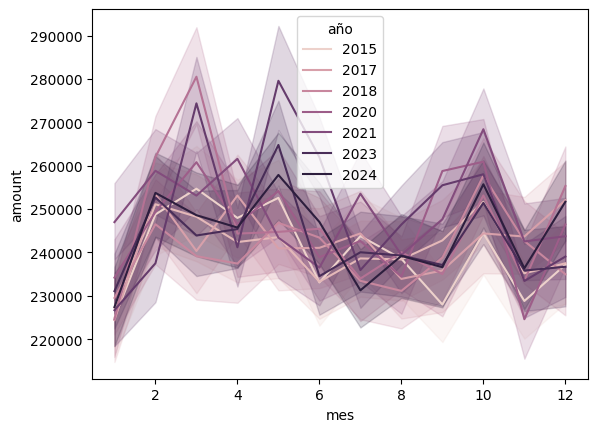

In [62]:
# Mostra la visualització final

# He provado con el heatmap pero si pongo los datos dentro de las celdas, no se leen, y si no los incluyo, no es práctico de leer
# Aunque no me parece perfecto, me acabo decidiendo por un gráfico de líneas, ya que permite comparar la evolución de la facturación mensual entre los distintos años
# Esto permite indentificar posibles patrones estacionales que se repitan

sns.lineplot(
    data=df,
    x="mes",
    y="amount",
    hue="año",
    estimator="sum"
)

In [63]:
# Interpreta què implica per al negoci.

'''
En el gráfico no se observan patrones suficientemente constantes (que se repitan año a año) como para afirmar una estacionalidad clara/contundente en las ventas.
Hay variaciones entre los meses, pero los picos más elevados o menores no tienen porqué coincidir el mismo mes cada año, no se repiten de manera consistente.
Sin embargo, sí parecería que en mayo y en octubre hay cierta tendencia al incremento de la facturación en la mayoría de los años, mientras que en noviembre parece ser habitual una disminución.

Para el negocio, estos datos podrían inclinarse a que los meses de mayo y octubre son los periodos con más actividad comercial, lo cual puede ayudar a apostar por
hacer planificaciones de stock o campañas de marketing antes, aunque deberían estudiarse otros factores ya que no se puede garantizar que sea dada la estacionalidad
'''


'\nEn el gráfico no se observan patrones suficientemente constantes (que se repitan año a año) como para afirmar una estacionalidad clara/contundente en las ventas.\nHay variaciones entre los meses, pero los picos más elevados o menores no tienen porqué coincidir el mismo mes cada año, no se repiten de manera consistente.\nSin embargo, sí parecería que en mayo y en octubre hay cierta tendencia al incremento de la facturación en la mayoría de los años, mientras que en noviembre parece ser habitual una disminución.\n\nPara el negocio, estos datos podrían inclinarse a que los meses de mayo y octubre son los periodos con más actividad comercial, lo cual puede ayudar a apostar por\nhacer planificaciones de stock o campañas de marketing antes, aunque deberían estudiarse otros factores ya que no se puede garantizar que sea dada la estacionalidad\n'

TERCERA PREGUNTA
» Anàlisi de concentració i variabilitat (tria UNA opció)

--> TRABAJARÉ SOBRE ESTA OPCIÓN
Opció A – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

Combinar transaccions, la taula pont i productes.

Calcular ingressos per producte amb un groupby, sum y sort.

Selecciona els top N productes: 15 per exemple.

Escollir una visualització adequada per analitzar dispersió.

*Opció B – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)*
*Hi ha usuaris que han deixat de comprar recentment?*
*Passos orientatius:*
*Identificar l'última compra per usuari.*
*Calcular el temps des de l'última compra.*
*Visualitzar la distribució del temps des de l'última compra.*



In [64]:
# Descriu breument els passos seguits.

'''
Los pasos a seguir seran similares a los orientativos propuestos en el enunciado:
- Juntar las tablas necesarias (transactions, products y tabla puente) para obtener la informaicón sobre pagos, productos.. necesaria
- Agrupamos la info con groupby para tener una fila por producto
- Calculamos los ingresos por producto con sum y sort
- Hago el top 15
'''

'\nLos pasos a seguir seran similares a los orientativos propuestos en el enunciado:\n- Juntar las tablas necesarias (transactions, products y tabla puente) para obtener la informaicón sobre pagos, productos.. necesaria\n- Agrupamos la info con groupby para tener una fila por producto\n- Calculamos los ingresos por producto con sum y sort\n- Hago el top 15\n'

In [65]:
# PASO 0 --> importar librerías y cargar archivos

#en este caso, solo hace falta importar un archivo

df3 = pd.read_csv("s2e8_products.csv") # cargamos el archivo que indica el enunciado, con la especificación de indicar el separador

df3.sample(5)

,id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
2,3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2,Food,Daily Pantry,$107.07,2013-08-18
42,43,duel,$59.80,#5b5b5b,0.6,WH-38,Electronics,Voltix,$38.78,2013-09-13
23,24,south duel tourney,$48.99,#aaaaaa,2.1,WH-19,Sports,MotionLab,$24.26,2013-06-07
54,55,Tully maester,$3.83,#6d6d6d,0.6,WH-50,Books,NorthPress,$2.49,2013-06-04
17,18,Karstark warden,$148.91,#c4c4c4,0.8,WH-13,Beauty,CareLab,$47.62,2013-07-11


In [66]:
# Para este ejercicio, deberemos utilizar la tabla de products (df3), transactions (df) y tendremos que hacer una taba puente (df_trans_prod)

df.columns

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes', 'hora', 'dia', 'año'],
      dtype='object')

In [67]:
# Seguimos consultando información necesaria para crear la tabla puente y juntarlas. En product_ids, como sospechava por el plural, hay varios números separados por comas, un string

df["product_ids"].head()

,product_ids
0,"75, 73, 98"
1,3
2,"92, 85, 36, 23"
3,"5, 27"
4,"38, 32, 82, 62"


In [68]:
#Para crear la tabla puente, primero haré una copia y luego split para separar los id's

df_trans_prod = df[["id", "product_ids"]].copy()

df_trans_prod.sample(5)

,id,product_ids
43661,58E3193A-F2D9-4ED4-B559-A2A97E8FEA18,"89, 70, 5"
63270,EF7760A4-22F9-4C12-B13D-0BE90EFE0FBD,"64, 87"
82536,988F0ABF-32C5-41EC-9A16-43FA63432F30,"4, 55, 68, 20"
63650,881A8FB4-58AF-48FD-A1B6-3484762F4ADF,55
38689,19384669-34A0-4BC2-9D6C-81FC8D5B9A70,"25, 5, 75, 39"


In [69]:
df_trans_prod["product_ids"] = df_trans_prod["product_ids"].str.split(", ")

df_trans_prod.sample(3)

,id,product_ids
17203,ECD64FC8-F8ED-4493-9BF8-0E33E8F7A29C,"[93, 56, 73, 9]"
65852,486F6629-7688-40AA-81E2-17C6336E20B9,"[48, 96]"
81998,FED8DEBD-77EE-4D5B-8461-A36ADFC8DE6F,"[90, 9, 31, 75]"


In [70]:
# Ahora, mediante explode, hacemo que cada ítem de la columna sea una fila independiente
#Por facilitar legibilidad, cambiaremos el nombre de columna a singular con rename

df_trans_prod = df_trans_prod.explode("product_ids")

df_trans_prod = df_trans_prod.rename(
    columns={"product_ids": "product_id"}
)

df_trans_prod.head(5)

,id,product_id
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,75
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,73
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,98
1,09456357-8E9B-475A-8257-87A023699964,3
2,C47C7C84-C174-4973-A76B-825A9DB5582A,92


In [71]:
# Empezamos a juntar tablas. Primero la talba puente con products (df3)

# Al principio me da error porque son de tipos diferentes (object con int64). Primero hago la conversión

df_trans_prod["product_id"] = df_trans_prod["product_id"].astype(int)

df_trans_prod_prod = df_trans_prod.merge(
    df3,
    left_on="product_id",
    right_on="id"
)

df_trans_prod_prod.head(6)

# aquí, tenemos:
# id_x → ID de la transacción
# product_id → ID del producto
# id_y → ID del producto en df3

,id_x,product_id,id_y,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,75,75,giantsblood maester Karstark,$9.46,#f9f9f9,1.5,WH-70,Food,FreshBox,$6.46,2014-10-16
1,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,73,73,Dorne bastard,$114.09,#848484,1.0,WH-68,Electronics,PixelForge,$80.50,2014-05-27
2,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,98,98,Direwolf Littlefinger,$38.33,#bababa,2.0,WH-93,Sports,Trail&Co,$16.74,2014-07-26
3,09456357-8E9B-475A-8257-87A023699964,3,3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2,Food,Daily Pantry,$107.07,2013-08-18
4,C47C7C84-C174-4973-A76B-825A9DB5582A,92,92,Stannis warden,$168.49,#afafaf,1.4,WH-87,Food,Market&Co,$105.96,2014-11-13
5,C47C7C84-C174-4973-A76B-825A9DB5582A,85,85,bastard of north,$62.62,#474747,1.0,WH-80,Fashion,ModaNova,$29.51,2013-05-05


In [72]:
#Primero vamos  aconvertir el precio a tipo numérico para poder operar con él

df_trans_prod_prod["price"] = (
    df_trans_prod_prod["price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

df_trans_prod_prod["price"]

,price
0,9.46
1,114.09
2,38.33
3,171.13
4,168.49
...,...
253386,124.04
253387,92.65
253388,194.29
253389,158.29


In [73]:
# ahora miramos que ingresos genera cad aproducto

ingresos_producto = (
    df_trans_prod_prod
    .groupby(["product_id", "product_name"])["price"] # agrupo lo que tiene que ver con un mismo producto
    .sum() # sumo la cantidad cada vez que aparece ese producto
    .sort_values(ascending=False) # ordeno de mayor a menor
)

ingresos_producto.name = "ingresos" #para no confundirnos con 'price'

ingresos_producto.sample(10)

,,ingresos
product_id,product_name,
11,Karstark Dorne,127878.10
60,rock Renly,171770.56
49,the giantsblood maester,134927.61
81,the duel,39183.03
75,giantsblood maester Karstark,23281.06
52,riverlands the duel,83654.08
29,Tully maester Tarly,440572.00
12,duel Direwolf,464532.80
84,Karstark Tully Dorne,236455.95


In [74]:
# hacems el top15 (ingresos_producto ya está ordenado), y lo convertimos a df

top_15 = ingresos_producto.head(15).reset_index()

top_15

# con esta información podemos responder a qué productos generan más ingresos

,product_id,product_name,ingresos
0,39,warden,505587.15
1,64,Direwolf,502352.16
2,67,Winterfell,500038.88
3,15,Stannis warden,492525.15
4,93,Littlefinger Tarly Stark,488241.00
5,62,the duel,481608.06
6,86,Stark kingsblood,478322.88
7,63,Jade tatooine dooku,476353.08
8,16,the duel warden,471813.28
9,12,duel Direwolf,464532.80


In [75]:
# Mostra la visualització final.

In [76]:
# Interpreta què implica per al negoci.

QUARTA PREGUNTA
» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

In [77]:
# Descriu breument els passos seguits.

In [78]:
'''
Passos orientatius:
Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.
Construir una taula agregada utilitzant crosstab.
Visualitzar amb un heatmap.
'''

"\nPassos orientatius:\nCrear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.\nConstruir una taula agregada utilitzant crosstab.\nVisualitzar amb un heatmap.\n"

In [79]:
#ahora vamos a responder a la segunda parte del enunciado, "con qué variabilidad"
#ver si esos ingresos son estables o no
#para ello, añadiré la columna mes a nuestro df, para ver como fluctuan los ingresos mensualmente

df["timestamp"] = pd.to_datetime(df["timestamp"]) #convertimos al formato correcto para solucionar el error que da el código

df_trans_prod_prod["mes"] = df_trans_prod_prod["id_x"].map(
    df.set_index("id")["timestamp"].dt.to_period("M")
)

df_trans_prod_prod[["id_x", "mes"]].head()

,id_x,mes
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,2018-12
1,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,2018-12
2,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,2018-12
3,09456357-8E9B-475A-8257-87A023699964,2024-05
4,C47C7C84-C174-4973-A76B-825A9DB5582A,2018-11


In [80]:
# ahora vamos a quedarnos solo con los id's que estén presentes en el top15 (ya que nos interesan esos productos)

df_top15 = df_trans_prod_prod[
    df_trans_prod_prod["product_id"].isin(top_15["product_id"])
].copy()

df_top15[["product_id", "product_name", "price", "mes"]].head()

,product_id,product_name,price,mes
7,23,riverlands north,169.96,2018-11
11,32,north,178.28,2020-11
13,62,the duel,188.94,2020-11
15,64,Direwolf,195.62,2021-05
17,12,duel Direwolf,181.60,2022-05


In [81]:
ingresos_mensuales = (
    df_top15
    .groupby(["product_id", "product_name", "mes"])["price"] #juntamos todas las veces que aparece el roducto
    .sum() # sumamos los precios
    .reset_index(name="ingresos") #para que no quede como serie sino como df
)

ingresos_mensuales.head(13)

# ahora tenemos una tabla que nos enseña los ingresos de cada producto, mes a mes

,product_id,product_name,mes,ingresos
0,12,duel Direwolf,2015-01,3268.8
1,12,duel Direwolf,2015-02,4358.4
2,12,duel Direwolf,2015-03,3268.8
3,12,duel Direwolf,2015-04,4721.6
4,12,duel Direwolf,2015-05,3450.4
5,12,duel Direwolf,2015-06,3450.4
6,12,duel Direwolf,2015-07,4540.0
7,12,duel Direwolf,2015-08,3995.2
8,12,duel Direwolf,2015-09,3813.6
9,12,duel Direwolf,2015-10,4358.4


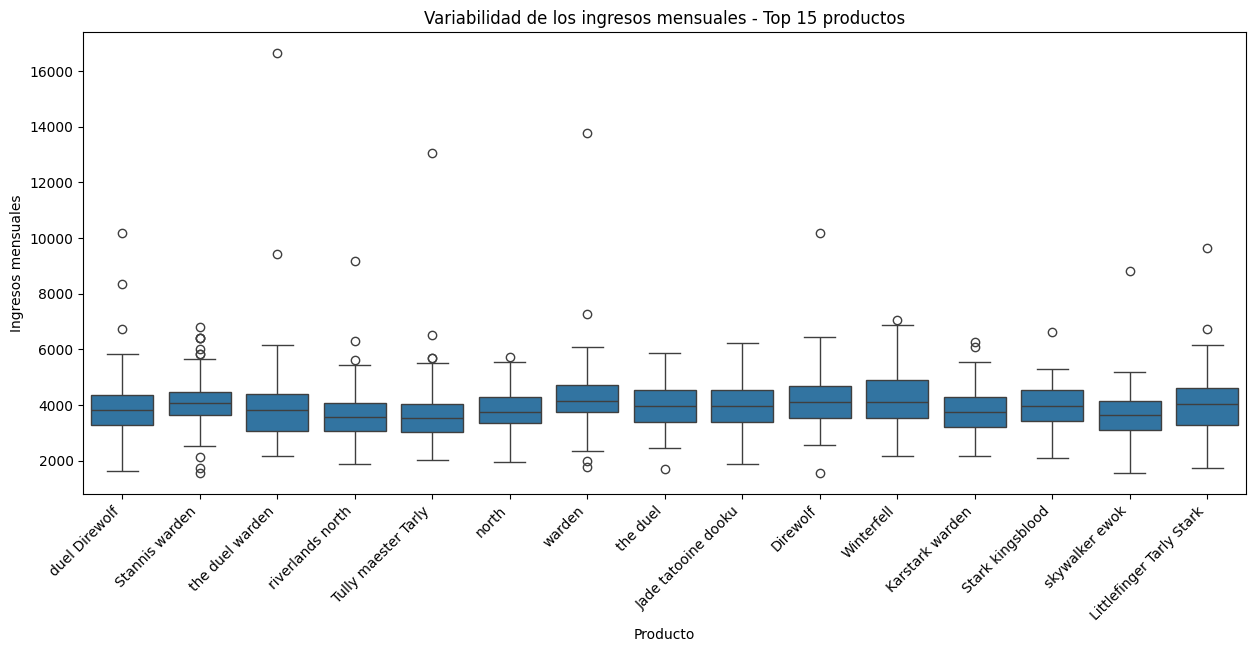

In [82]:
# Mostra la visualització final.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6)) # para que el gráfico sea más ancho y más fácil de leer

sns.boxplot( #indico de donde saco los datos y que variables van en cada eje
    data=ingresos_mensuales,
    x="product_name",
    y="ingresos"
)

# personalizo un poco la visualización
plt.xticks(rotation=45, ha="right") #por ejemplo, rodando los nombres para que se lean mejor (horizontalmente no cabrían y en diagonal es más cómodo que vertical)
plt.xlabel("Producto")
plt.ylabel("Ingresos mensuales")
plt.title("Variabilidad de los ingresos mensuales - Top 15 productos")

plt.show()

In [83]:
# Interpreta què implica per al negoci.

# En el boxplot podemos ver que las cajas más pequeñas significan que los ingresos son más parecidos (por lo tanto, poca variabilidad) mintras que una caja más alargada implica más cambio entre meses
# Por otro lado, los puntos sueltos son, como ya habíamos visto, ingresos mucho más altos o bajos de lo habitual.

'''
En nuestro caso, la mayoría se ubican entre 3800 y 42000 mensuales aproximadamente (dólares)
De este modo, como vista general, los 15 productos tienen una variabilidad simialr

En general los productos presentan ingresos mensuales relativamente estables y en rangos similares, aunque existen algunas diferencias en su variabilidad y varios picos excepcionales.
Para el negocio sería interesante estudiar qué provoca esos picos (por si estan relacionados con campañas o fechas señaladas, por ejemplo) y así preever mejor al demanda y la previsión de stock.
'''

'\nEn nuestro caso, la mayoría se ubican entre 3800 y 42000 mensuales aproximadamente (dólares)\nDe este modo, como vista general, los 15 productos tienen una variabilidad simialr\n\nEn general los productos presentan ingresos mensuales relativamente estables y en rangos similares, aunque existen algunas diferencias en su variabilidad y varios picos excepcionales.\nPara el negocio sería interesante estudiar qué provoca esos picos (por si estan relacionados con campañas o fechas señaladas, por ejemplo) y así preever mejor al demanda y la previsión de stock.\n'

## Nivell 2 – Anàlisi relacional i patrons avançats

## Exercici 1: Anàlisi de productes i captació d'usuaris
🎯 Objectiu: Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.
Els productes que generen més ingressos també impulsen el creixement del negoci mitjançant la captació de nous usuaris, o bé el negoci depèn principalment d'usuaris recurrents comprant els mateixos productes?

Passos orientatius:

1. Combina les taules necessàries.

2. Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.

3. Agrega la informació per producte i calcula les mètriques següents:

Ingressos totals.
Variabilitat dels ingressos.
Nombre de nous usuaris.
Percentatge de nous usuaris sobre el total de compradors del producte.

4. Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:

Captador: alta captació de nous usuaris.
Recurrent: ingressos elevats però baixa captació.
Emergent: baixa facturació però bona captació.
Estancat: baixos ingressos i baixa captació.
5. Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:

Eix X → ingressos totals per producte.
Eix Y → nombre de nous usuaris.
Mida del punt → variabilitat dels ingressos.
Color del punt → tipologia analítica del producte.
📌 Nota important

No es tracta només de mostrar gràfics, sinó d'interpretar què implica per al negoci no captar nous usuaris.

In [88]:
# Recuerdo las columnas de las tablas que voy a necesitar. Empiezo por transactions

df.columns

Index(['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes', 'hora', 'dia', 'año'],
      dtype='object')

In [89]:
# Sigo con products

df3.columns

Index(['id', 'product_name', 'price', 'colour', 'weight', 'warehouse_id',
       'category', 'brand', 'cost', 'launch_date'],
      dtype='object')

In [107]:
# Aprovecho la tabla puente que he creado en ejercicios anteriores entre transactions y products

df_trans_prod.columns

Index(['id', 'product_id'], dtype='object')

In [96]:
# Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.
# 1. Ordenar las transacciones por usuario y por timestamp (ascendiente por defecto)


df = df.sort_values(["user_id", "timestamp"])

df[["user_id", "id", "timestamp"]]

,user_id,id,timestamp
67717,1,6ED484BC-2DBB-47CF-B77E-12752FCB43E2,2015-05-08 18:09:41
80229,1,F3E47D02-CE43-4B87-8C3F-5B0D14526F41,2015-11-04 13:01:34
37941,1,97693F29-668B-4289-8E37-0239AA395A97,2015-12-20 18:06:59
19673,1,7F5C1DBA-F34B-4A4F-BCE9-51B6FF2AD633,2016-07-04 21:06:10
49357,1,02800DB7-FAF0-4602-B28C-76FF7F8897EE,2016-09-22 02:43:55
...,...,...,...
78415,5000,3CB22B62-2192-4848-AD2C-1368BA20961C,2023-07-25 17:18:17
80190,5000,6AE1C6C0-3D41-4E61-B083-F0C93E950683,2023-09-21 00:50:22
91016,5000,A3ED27F5-A495-4407-A259-AAD4FA7524AC,2024-04-04 09:49:20
52541,5000,650F6475-6306-4A7D-9715-7C8CA072DFA0,2024-09-04 14:58:06


In [104]:
# Para definir "es nou usuari" usaremos .duplicated en nuestro df ya ordenado y de cada usuario (user_id) nos quedaremos con la 1a


df["es_nou_usuari"] = ~df.duplicated(
    subset="user_id",
    keep="first"
)

df["es_nou_usuari"].sample(10)

,es_nou_usuari
68963,False
86270,False
26946,False
41449,False
83410,False
76111,False
13505,False
52579,True
28471,False
63337,False


In [105]:
# Agrega la informació per producte i calcula les mètriques següents:
'''
- Ingressos totals.
- Variabilitat dels ingressos.
- Nombre de nous usuaris.
- Percentatge de nous usuaris sobre el total de compradors del producte.
'''

'\n- Ingressos totals. \n- Variabilitat dels ingressos. \n- Nombre de nous usuaris. \n- Percentatge de nous usuaris sobre el total de compradors del producte.\n'

In [113]:
# añadimos la nueva columna para tener la info más accesible

df_trans_prod_nou = df_trans_prod.merge(
    df[["id", "user_id", "es_nou_usuari"]],
    on="id"
)

df_trans_prod_nou.head(3)

,id,product_id,user_id,es_nou_usuari
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,75,2313,False
1,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,73,2313,False
2,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,98,2313,False


In [120]:
# Ingressos totals --> sumar amount (de cada producto)

# primero traigo la columna amount para poder operar con ella
df_trans_prod_nou = df_trans_prod_nou.merge(
    df[["id", "amount"]],
    on="id"
)

df_trans_prod_nou.columns

Index(['id', 'product_id', 'user_id', 'es_nou_usuari', 'amount'], dtype='object')

In [121]:
df_trans_prod_nou.head(2)

,id,product_id,user_id,es_nou_usuari,amount
0,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,75,2313,False,176.45
1,CDDA7E40-544D-47BB-A4ED-671DD8A950D9,73,2313,False,176.45


In [123]:
'''
# elimino la columna que se me ha duplicado y cambio el nombre a la otra para dejarlo como debería estar

df_trans_prod_nou = df_trans_prod_nou.drop(columns="amount_y")

df_trans_prod_nou = df_trans_prod_nou.rename(columns={"amount_x":"amount"})

df_trans_prod_nou.columns
'''

'\n# elimino la columna que se me ha duplicado y cambio el nombre a la otra para dejarlo como debería estar\n\ndf_trans_prod_nou = df_trans_prod_nou.drop(columns="amount_y")\n\ndf_trans_prod_nou = df_trans_prod_nou.rename(columns={"amount_x":"amount"})\n\ndf_trans_prod.columns\n'

In [124]:
# Ahora si, calculo los ingresos

df_trans_prod_nou.groupby("product_id")["amount"].sum()

,amount
product_id,
1,1015105.09
2,638149.57
3,1079086.36
4,818632.36
5,1078063.70
...,...
96,675803.26
97,778754.21
98,720660.32


In [127]:
# Variabilitat dels ingressos --> calcular std

# primero extraigo la información temporal que me interesa de df (transactions)ç
df["mes"] = df["timestamp"].dt.to_period("M")

In [132]:
# luego la añado al df con el que estoy trabajando df_trans_prod_nou para poder operar bien con ella
df_trans_prod_nou = df_trans_prod_nou.merge(
    df[["id", "mes"]],
    on="id"
)

df_trans_prod_nou.columns

Index(['id', 'product_id', 'user_id', 'es_nou_usuari', 'amount', 'mes_x',
       'mes_y'],
      dtype='object')

In [133]:
'''
# elimino la columna que se me ha duplicado y cambio el nombre a la otra para dejarlo como debería estar

df_trans_prod_nou = df_trans_prod_nou.drop(columns="mes_y")

df_trans_prod_nou = df_trans_prod_nou.rename(columns={"mes_x":"mes"})

df_trans_prod_nou.columns
'''

Index(['id', 'product_id', 'user_id', 'es_nou_usuari', 'amount', 'mes'], dtype='object')

In [135]:
# para ver la variabilidad, primero calculo los ingreoss por mes. Agrupo por producto (id) y por mes con groupby, seguidamente hacemos la suma

ingresos_mensuales = (
    df_trans_prod_nou
    .groupby(["product_id", "mes"])["amount"]
    .sum()
    .reset_index()
)

ingresos_mensuales.sample(10)

,product_id,mes,amount
4826,41,2017-03,9640.02
5992,50,2024-05,6429.79
1143,10,2020-04,11631.22
1579,14,2016-08,10448.27
7748,65,2020-09,5987.60
3615,31,2016-04,8860.01
8655,73,2016-04,5665.86
6726,57,2015-07,11074.64
2754,23,2024-07,8350.07
5291,45,2015-12,7373.32


In [139]:
# y ahora utilizamos el estadístico std sobre "ingresos_mensuales"

variabilidad = (
    ingresos_mensuales
    .groupby("product_id")["amount"]
    .std().round(2)
)

variabilidad.sample(10)

,amount
product_id,
75,2609.20
5,2219.18
80,1655.71
58,1925.74
56,2122.28
81,1212.44
6,3132.66
77,1900.25
43,1474.42


In [145]:
# Nombre de nous usuaris --> quedarme con las filas donde es_nou_usuari sea true

# primero voy a filtrar los nuevos usuarios
nous_usuaris = df_trans_prod_nou[df_trans_prod_nou["es_nou_usuari"]]

nous_usuaris.head()


,id,product_id,user_id,es_nou_usuari,amount,mes
39,44CD5F49-4D07-4E8C-B87E-DE51EB730676,7,1829,True,616.26,2015-05
40,44CD5F49-4D07-4E8C-B87E-DE51EB730676,64,1829,True,616.26,2015-05
41,44CD5F49-4D07-4E8C-B87E-DE51EB730676,16,1829,True,616.26,2015-05
42,44CD5F49-4D07-4E8C-B87E-DE51EB730676,34,1829,True,616.26,2015-05
89,B40282E9-E8F7-46BA-9B18-D64D901752C0,10,1606,True,130.28,2015-04


In [167]:
# ahora los agrupo por producto, y con .nunique() me aseguro que un usuario nuevo solo cuente una vez ("cuantos user_id distintos hay entre los usuarios nuevos")

quantitat_nous = nous_usuaris.groupby("product_id")["user_id"].nunique()

quantitat_nous

,user_id
product_id,
1,108
2,126
3,126
4,122
5,152
...,...
96,100
97,120
98,119


In [168]:
# Percentatge de nous usuaris sobre el total de compradors del producte --> dividir el nº de nuevos usuarios (quantitat_nous) entre el nº de compradores totales (compradors_totals) x 100

# Para crear compradors_totals, volvemos a nuestro df, agrupo por producto y contamos cuantos usuarios distintos (nunique) han comprado el producto

compradors_totals = df_trans_prod_nou.groupby("product_id")["user_id"].nunique()

compradors_totals.sample(5)

,user_id
product_id,
45,1876
17,1932
16,1929
18,1952
35,1968


In [172]:
porcentaje = (quantitat_nous / compradors_totals * 100).round(2)

porcentaje

,user_id
product_id,
1,5.68
2,6.42
3,6.52
4,6.24
5,7.82
...,...
96,5.19
97,6.28
98,6.13


In [210]:
# Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:
'''
- Captador: alta captació de nous usuaris. --> ANOTACIÓN_ voy a tener en cuent atambién alta facturación, ya que si no, puede solaparse con "Emergent"
- Recurrent: ingressos elevats però baixa captació.
- Emergent: baixa facturació però bona captació.
- Estancat: baixos ingressos i baixa captació.
'''

# Primero debemos definir que son ingresos altos o bajos y captación alta o baja. Considero que lo más sencillo es basarnos en la mediana
# si ingresos > mediana, ingresos altos
# si ingresos < mediana, ingresos bajos
# si captación > mediana, captación alta
# si captación < mediana, captación baja

'\n- Captador: alta captació de nous usuaris. --> ANOTACIÓN_ voy a tener en cuent atambién alta facturación, ya que si no, puede solaparse con "Emergent"\n- Recurrent: ingressos elevats però baixa captació. \n- Emergent: baixa facturació però bona captació. \n- Estancat: baixos ingressos i baixa captació. \n'

In [198]:
# reunimos toda la información sobre las métricas que nos interesan en una tabla

# al intentar concat, me salen varios NaN, lo que me indica que la estructura no era la misma, voy a hacer comprobaciones antes de seguir
'''
tabla_productos = pd.concat([
    ingresos_mensuales,
    variabilidad,
    quantitat_nous,
    porcentaje
], axis=1)

tabla_productos.sample(5)
'''


'\ntabla_productos = pd.concat([\n    ingresos_mensuales,\n    variabilidad,\n    quantitat_nous,\n    porcentaje\n], axis=1)\n\ntabla_productos.sample(5)\n'

In [199]:
print(ingresos_mensuales.head())

   product_id      mes    amount
0           1  2015-01   6780.29
1           1  2015-02   7704.59
2           1  2015-03  11602.20
3           1  2015-04   4363.44
4           1  2015-05  10035.26


In [200]:
print(variabilidad.head())

product_id
1    2266.22
2    1539.16
3    2851.60
4    2172.14
5    2219.18
Name: amount, dtype: float64


In [201]:
print(quantitat_nous.head())

product_id
1    108
2    126
3    126
4    122
5    152
Name: user_id, dtype: int64


In [202]:
print(porcentaje.head())

product_id
1    5.68
2    6.42
3    6.52
4    6.24
5    7.82
Name: user_id, dtype: float64


In [203]:
# vemos que el problema está en ingresos mensuales

ingresos = (
    ingresos_mensuales
    .groupby("product_id")["amount"]
    .sum()
)

ingresos

,amount
product_id,
1,1015105.09
2,638149.57
3,1079086.36
4,818632.36
5,1078063.70
...,...
96,675803.26
97,778754.21
98,720660.32


In [204]:
#vuelvo a probar de concatenar

tabla_productos = pd.concat([
    ingresos,
    variabilidad,
    quantitat_nous,
    porcentaje
], axis=1)

tabla_productos.sample(5)

# ahora si

,amount,amount,user_id,user_id
product_id,,,,
6,979615.98,3132.66,105,5.43
2,638149.57,1539.16,126,6.42
17,853358.06,1878.36,131,6.78
49,752473.67,1482.30,140,7.15
14,996532.65,1727.49,121,6.21


In [205]:
# los nombres pueden generar bastante confusión, así que vamos a renombrar las columnas (aparentemente conservan el nombre original al ahcer concat)

tabla_productos.columns = [
    "ingresos_totales",
    "variabilidad_ingresos",
    "nuevos_usuarios",
    "porcentaje_nuevos"
]

tabla_productos.head()

,ingresos_totales,variabilidad_ingresos,nuevos_usuarios,porcentaje_nuevos
product_id,,,,
1,1015105.09,2266.22,108,5.68
2,638149.57,1539.16,126,6.42
3,1079086.36,2851.60,126,6.52
4,818632.36,2172.14,122,6.24
5,1078063.70,2219.18,152,7.82


In [207]:
# Ahora vamos a calcular las medias que nos interesan

mediana_ingresos = tabla_productos["ingresos_totales"].mean().round(2)

print("Media ingresos")
mediana_ingresos

Media ingresos


np.float64(886323.3)

In [208]:
mediana_nuevos = tabla_productos["nuevos_usuarios"].mean().round(2)

print("Media nuevos")
mediana_nuevos

Media nuevos


np.float64(125.27)

In [209]:
# añadimos la columna de tipologia
# primero le añado un valor constante (en este caso, la palabra "tipologia")

tabla_productos["tipologia"] = "tipologia"

tabla_productos.head()

,ingresos_totales,variabilidad_ingresos,nuevos_usuarios,porcentaje_nuevos,tipologia
product_id,,,,,
1,1015105.09,2266.22,108,5.68,tipologia
2,638149.57,1539.16,126,6.42,tipologia
3,1079086.36,2851.60,126,6.52,tipologia
4,818632.36,2172.14,122,6.24,tipologia
5,1078063.70,2219.18,152,7.82,tipologia


In [211]:
# ahora voy a calcular y añadir la etiqueta que corresponda: captador, recurrente, emergente, estancado

#PARA ETIQUETAR COMO CAPTADOR
tabla_productos.loc[
    (tabla_productos["ingresos_totales"] > mediana_ingresos) &
    (tabla_productos["nuevos_usuarios"] > mediana_nuevos),
    "tipologia"
] = "Captador"

#PARA ETIQUETAR COMO RECURRENTE
tabla_productos.loc[
    (tabla_productos["ingresos_totales"] > media_ingresos) &
    (tabla_productos["nuevos_usuarios"] <= media_nuevos),
    "tipologia"
] = "Recurrent"

#PARA ETIQUETAR COMO EMERGENTE
tabla_productos.loc[
    (tabla_productos["ingresos_totales"] <= media_ingresos) &
    (tabla_productos["nuevos_usuarios"] > media_nuevos),
    "tipologia"
] = "Emergent"

#PARA ETIQUETAR COMO ESTANCADO
tabla_productos.loc[
    (tabla_productos["ingresos_totales"] <= media_ingresos) &
    (tabla_productos["nuevos_usuarios"] <= media_nuevos),
    "tipologia"
] = "Estancat"


In [212]:
# comprobamos
tabla_productos.head(10)

,ingresos_totales,variabilidad_ingresos,nuevos_usuarios,porcentaje_nuevos,tipologia
product_id,,,,,
1,1015105.09,2266.22,108,5.68,Recurrent
2,638149.57,1539.16,126,6.42,Emergent
3,1079086.36,2851.60,126,6.52,Captador
4,818632.36,2172.14,122,6.24,Estancat
5,1078063.70,2219.18,152,7.82,Captador
6,979615.98,3132.66,105,5.43,Recurrent
7,771746.73,1661.58,112,5.65,Estancat
8,678414.72,1453.22,122,6.15,Estancat
9,824613.33,3775.02,130,6.67,Emergent


In [213]:
# veamos cuantos productos de cada tipo hay

tabla_productos["tipologia"].value_counts()

,count
tipologia,
Emergent,29
Recurrent,26
Captador,23
Estancat,22


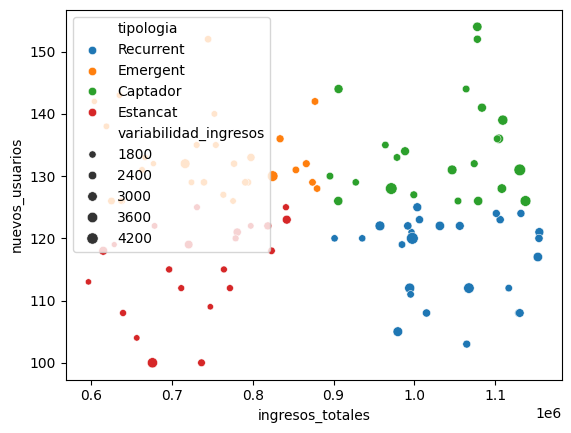

In [214]:
# Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:
'''
- Eix X → ingressos totals per producte.
- Eix Y → nombre de nous usuaris.
- Mida del punt → variabilitat dels ingressos.
- Color del punt → tipologia analítica del producte.

📌 Nota important
No es tracta només de mostrar gràfics, sinó d'interpretar què implica per al negoci no captar nous usuaris.
'''

sns.scatterplot(
    data=tabla_productos,
    x="ingresos_totales",
    y="nuevos_usuarios",
    size="variabilidad_ingresos",
    hue="tipologia"
)

plt.show()

In [215]:
# interpretación del gráfico e implicación para el negocio

'''
Tal como podemos observar, los productos Captadores (color verde) tienen una elevada capacidad de captación de nuevos usuarios (posición superior en el Eje Y) y generan bastantes ingresos (más a la derecha en el Eje X).
Estos productos son muy interesantes o destacables para el crecimiento del negocio

Los productos Recurrentes (azul) también generan ingresos elevados, sin embargo, tienen menos captación. Esto indica mayor dependencia de los clientes recurrentes para mantenerse.

Respecto los productos Emergentes (amarillo), a pesar de tener una facturación menor, los datos apoyan que consiguen captar a nuevos usuarios, lo cual nos indica un posible potencial de crecimiento.

En cuanto a los productos Estancados, podemos observar baja facturación y baja captación, lo que los situa en una posición menos favorable.

El tamaño de los puntos representa la variabilidad de los ingresos; los productos con puntos más grandes presentan mayores fluctuaciones en sus ingresos mensuales.

Para los negocios es importante la captación de nuevos usuarios ya que, si solo se depende de los recurrentes, puede suponer un riesgo a largo plazo por la dependencia que genera,
Por este motivo, sería recomendable potenciar estrategias de captación de nuevos usuarios, especialmente en aquellos productos que ya muestran capacidad para generar ingresos, sin perder la capacidad de mantener a los clientes recurrentes.
'''

'\nTal como podemos observar, los productos Captadores (color verde) tienen una elevada capacidad de captación de nuevos usuarios (posición superior en el Eje Y) y generan bastantes ingresos (más a la derecha en el Eje X).\nEstos productos son muy interesantes o destacables para el crecimiento del negocio\n\nLos productos Recurrentes (azul) también generan ingresos elevados, sin embargo, tienen menos captación. Esto indica mayor dependencia de los clientes recurrentes para mantenerse.\n\nRespecto los productos Emergentes (amarillo), a pesar de tener una facturación menor, los datos apoyan que consiguen captar a nuevos usuarios, lo cual nos indica un posible potencial de crecimiento.\n\nEn cuanto a los productos Estancados, podemos observar baja facturación y baja captación, lo que los situa en una posición menos favorable. \n\nEl tamaño de los puntos representa la variabilidad de los ingresos; los productos con puntos más grandes presentan mayores fluctuaciones en sus ingresos mensuale

Esta vez, de manera puntual no entrego los tres niveles sinó que finalizo aquí mi Sprint